## Загрузка исходных датасетов

- `load_from_cdaweb` - параметр, отвечающий за источник откуда будет произведена загрузка данных.
- `loader` - экзампляр класса, обеспичвающий загрузку данных.
- `get_*_data()` - соответственные методы по загрузке определённых данных.

| Вызов | Содержимое колонок |
|--------|---------------------|
| `get_ssc_data()` | **Time** — время; **Latitude**, **Longitude** — широта/долгота (GSM); **L** — L-шелл; **GSM_X**, **GSM_Y**, **GSM_Z** — позиция аппарата в GSM (км). |
| `get_fgm_data()` | **Time**; **GSM_Bx**, **GSM_By**, **GSM_Bz** — вектор магнитного поля в GSM (нТ). |
| `get_esa_data(particle="ion")` | **Time**; **GSM_Vix**, **GSM_Viy**, **GSM_Viz** — скорость ионов в GSM (км/с). |
| `get_esa_data(particle="electron")` | **Time**; **GSM_Vex**, **GSM_Vey**, **GSM_Vez** — скорость электронов в GSM (км/с). |
| `get_efi_data()` | **Time**; **GSM_Ex**, **GSM_Ey**, **GSM_Ez** — электрическое поле в GSM (единицы как в CDF, часто мВ/м). |
| `get_sta_data()` | **Time**; **GSM_Vsx**, **GSM_Vsy**, **GSM_Vsz** — скорость спутника в GSM (км/с). |
| `get_omn_data()` | **Time**; **FP** — динамическое давление солнечного ветра; **Bz_GSM** — компонента Bz в GSM. |

Общее: после загрузки отброшены строки без валидного **Time**, дубликаты по **Time** удалены. Интервал и спутник задаются в `config.reading`; OMNI — околоземный ряд, не привязан к букве спутника по смыслу данных.

In [1]:
from backend.src.io.loader import DataDownloading
from backend.src.config import config
from backend.src.processing.utils.h_parameter_range import show_h_parameter_range

In [2]:
load_from_cdaweb = False
loader = DataDownloading(config, load_from_cdaweb=load_from_cdaweb)

In [3]:
ssc_data = loader.get_ssc_data()
fgm_data = loader.get_fgm_data()
esa_ion_data = loader.get_esa_data(particle="ion")
# esa_electron_data = loader.get_esa_data(particle="electron")
efi_data = loader.get_efi_data()
sta_data = loader.get_sta_data()
omn_data = loader.get_omn_data()

## Пересечение промежутков

In [4]:
# from backend.src.processing import (
#     define_available_data,
# )
#
#
# ssc_intervals = define_available_data(ssc_data, "ssc", show_progress=False)
# sta_intervals = define_available_data(sta_data, "sta", show_progress=False)
# omn_intervals = define_available_data(omn_data, "omn", show_progress=False)
# efi_intervals = define_available_data(efi_data, "efi", show_progress=False)
# fgm_intervals = define_available_data(fgm_data, "fgm", show_progress=False)
# esa_ion_intervals = define_available_data(esa_ion_data, "esa_ion", show_progress=False)
#
# # overlaps_a = get_overlaps(ssc_intervals, sta_intervals)
# # overlaps_b = get_overlaps(omn_intervals, efi_intervals)
# # overlaps_c = fgm_intervals
# # overlaps_ab = get_overlaps(overlaps_a, overlaps_b)
# # overlaps_cd = get_overlaps(overlaps_c, esa_ion_intervals)
# # overlaps_abcd = get_overlaps(overlaps_ab, overlaps_cd)
#
# # print_intervals_summary(overlaps_abcd)

In [5]:
from backend.src.processing import AvailabilityIntervals
availability = AvailabilityIntervals(show_progress=True)

ssc_intervals = availability.from_dataframe(ssc_data, "ssc")
fgm_intervals = availability.from_dataframe(fgm_data, "fgm")
esa_ion_intervals = availability.from_dataframe(esa_ion_data, "esa_ion")
# esa_electron_intervals = availability.from_dataframe(esa_electron_data, "esa_electron")
efi_intervals = availability.from_dataframe(efi_data, "efi")
sta_intervals = availability.from_dataframe(sta_data, "sta")
omn_intervals = availability.from_dataframe(omn_data, "omn")

Определение интервалов: 100%|██████████| 320/320 [00:00<00:00, 25081.33it/s]


In [10]:
efi_intervals

1. 2017-01-01 13:12:02 - 2017-01-02 00:21:13
2. 2017-01-02 03:43:06 - 2017-01-02 05:25:06
3. 2017-01-02 18:49:06 - 2017-01-03 03:04:57
4. 2017-01-03 21:14:14 - 2017-01-03 23:59:59

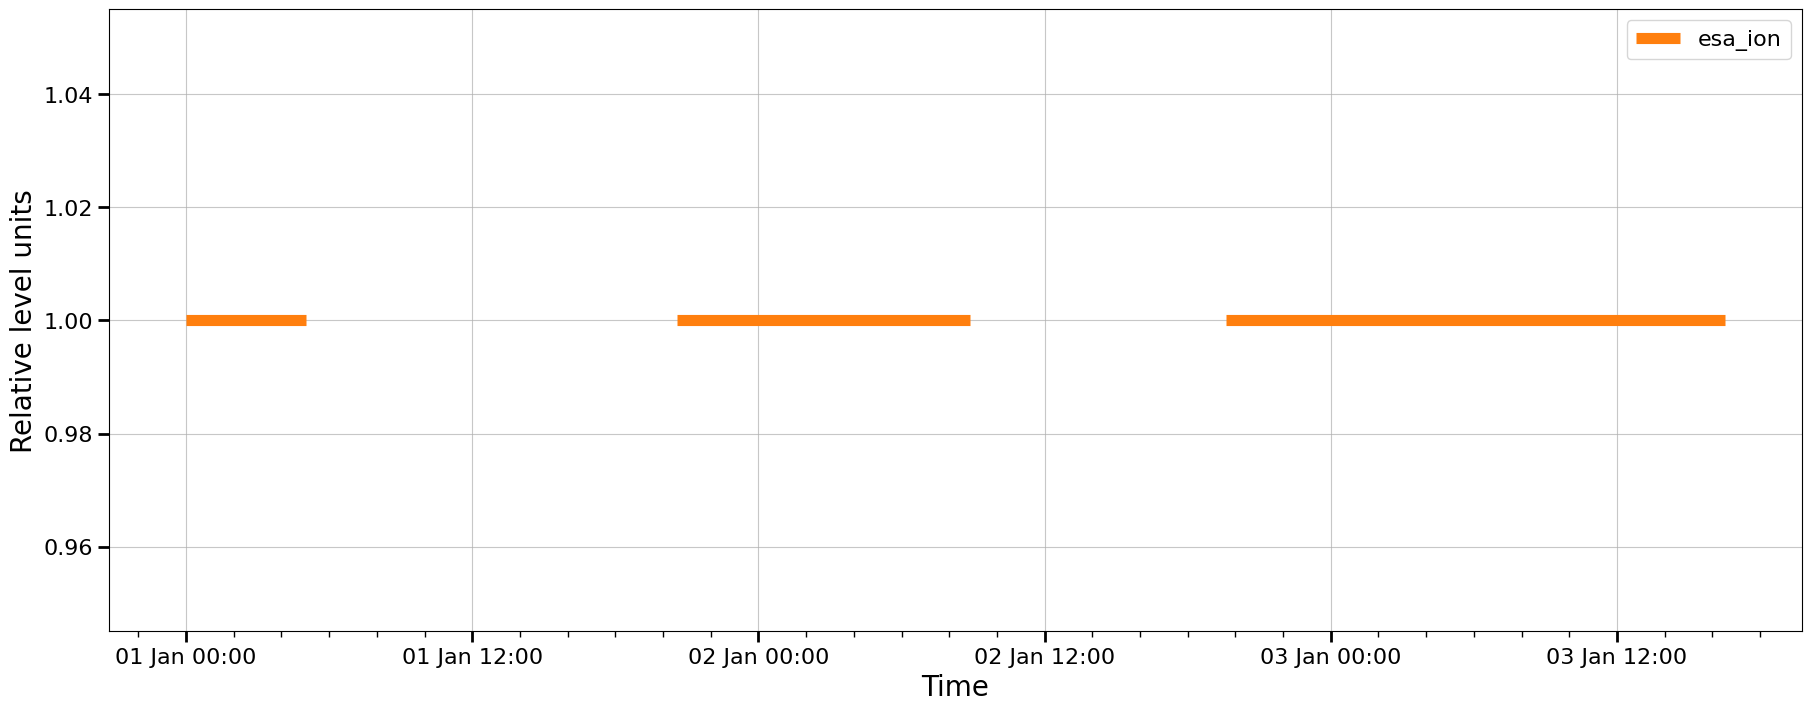

In [6]:
availability.show(esa_ion_data, esa_ion_intervals, "esa_ion")


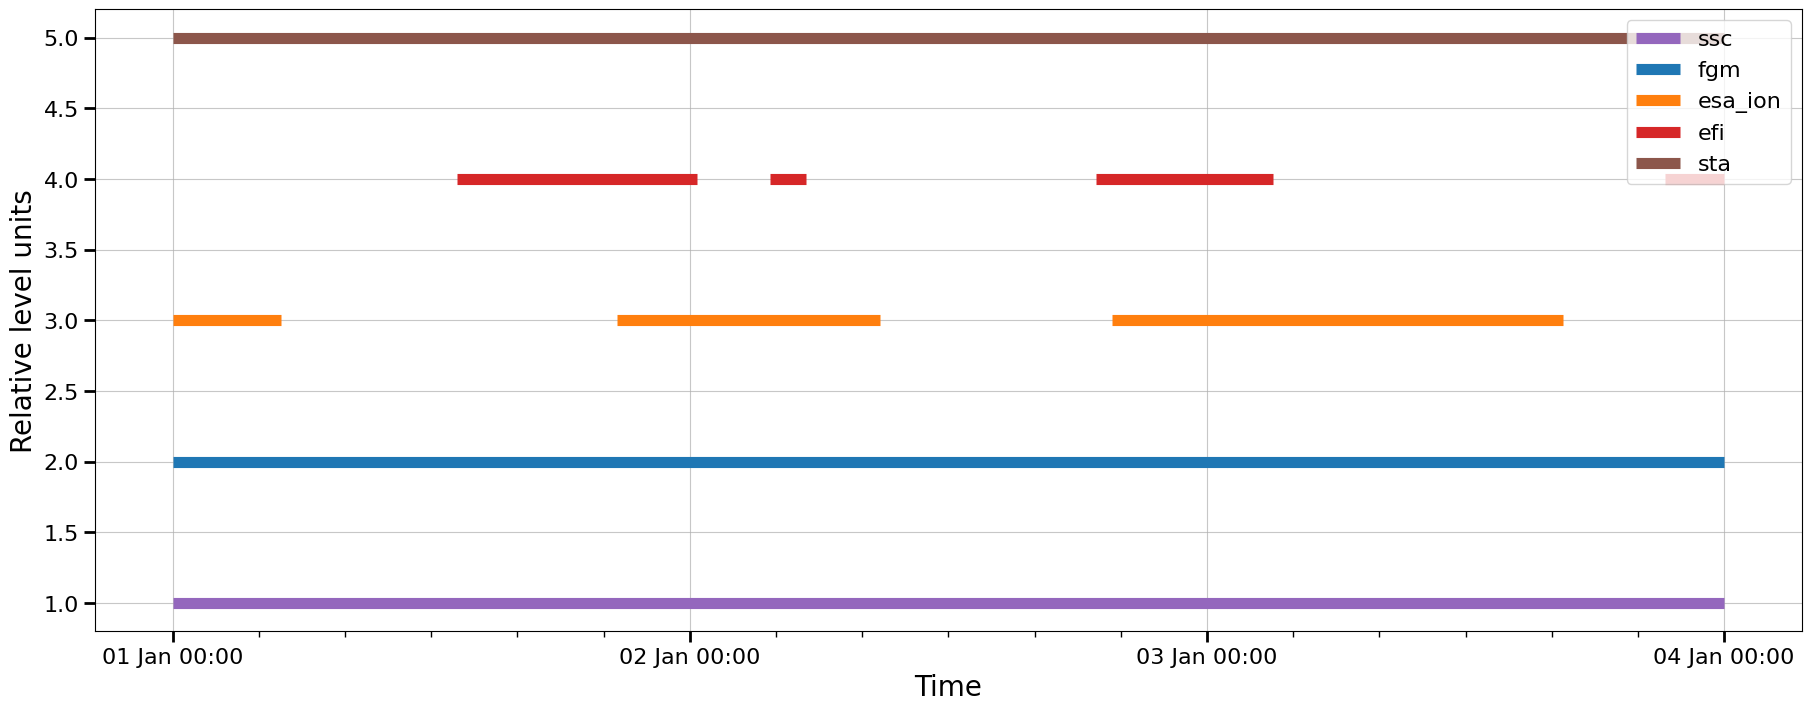

In [7]:
intervals_list = [
    {'intervals': ssc_intervals, "data_type": "ssc"},
    {'intervals': fgm_intervals, "data_type": "fgm"},
    {'intervals': esa_ion_intervals, "data_type": "esa_ion"},
    {'intervals': efi_intervals, "data_type": "efi"},
    {'intervals': sta_intervals, "data_type": "sta"},
]

availability.show_intervals(ssc_data, intervals_list)